In [2]:
import napari
import numpy as np
from aicsimageio import AICSImage

import pandas as pd
from skimage import measure


import tifffile as tf
import matplotlib.pyplot as plt
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from matplotlib import pyplot as plt
from os.path import sep
from skimage import io
from PIL import Image
import imageio


from skimage.measure import regionprops_table

import seaborn as sns

import czifile

import math

from pathlib import Path
import re

from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit


In [3]:
# on both fisher lab MAC and Sansa MACbook





data_dir = Path('mean signal value csv')
data_dir = Path.cwd() / 'mean signal value csv'

# 2. Grab every fly*_mean_signals.csv in there
csv_files = list(data_dir.glob('fly*_mean_signals.csv'))

# 3. Read them into a dict of DataFrames,
#    keyed by 'fly#'
data = {
    f.stem.replace('_mean_signals', ''): pd.read_csv(f)
    for f in csv_files
}

# 4. (Optional) Quick sanity‑check
for name, df in data.items():
    print(name, df.shape)

# 5. Assign each DataFrame to a variable named after its key
for fly_name, df in data.items():
    globals()[fly_name] = df

fly11 (18, 5)
fly7 (18, 5)
fly3 (18, 5)
fly8 (18, 5)
fly6 (18, 5)
fly10 (18, 5)
fly9 (18, 5)
fly5 (18, 5)
fly13 (18, 5)
fly1 (18, 5)
fly12 (18, 5)
fly4 (18, 5)


In [4]:
fly1

,glomerulus,mean_red,mean_green,total_red,total_green
0,glom_1,962.697885,159.971423,1.466291e+08,34883582.0
1,glom_2,946.590984,154.323150,3.136736e+08,70510562.0
2,glom_3,935.043142,156.905301,2.470303e+08,56387721.0
3,glom_4,843.692592,149.614978,2.680443e+08,63721847.0
4,glom_5,864.663045,116.448605,1.822358e+08,35904963.0
5,glom_6,850.902800,141.206419,1.709262e+08,39416768.0
6,glom_7,1274.272695,227.465083,1.204585e+09,242893358.0
7,glom_8,754.813273,94.204003,1.262476e+08,21812208.0
8,glom_9,728.383596,107.993840,8.201922e+07,15845884.0
9,glom_10,778.947420,132.570087,1.971667e+08,42273494.0


In [5]:
fly_subtype = pd.DataFrame({
    'fly': [
        'fly1','fly3','fly4','fly5','fly6',
        'fly7','fly8','fly9','fly10','fly11',
        'fly12','fly13'
    ],
    'subtype': [
        'L3R6','L7R2','L3R6','L1L9R8','L7R2',
        'L1L9R8','L6R3','L3R6','L1L9R8','L2R7',
        'L8R1R9','L7R2'
    ]
})

In [6]:
tokens = fly_subtype['subtype'].str.findall(r'[LR]\d+')

# 2. Figure out the maximum number of tokens any row has
max_parts = tokens.map(len).max()

# 3. Create column names dynamically (part1, part2, …)
col_names = [f'part{i+1}' for i in range(max_parts)]

# 4. “Unpack” the lists of tokens into separate columns
fly_subtype[col_names] = pd.DataFrame(tokens.tolist(), index=fly_subtype.index)

fly_subtype

,fly,subtype,part1,part2,part3
0,fly1,L3R6,L3,R6,None
1,fly3,L7R2,L7,R2,None
2,fly4,L3R6,L3,R6,None
3,fly5,L1L9R8,L1,L9,R8
4,fly6,L7R2,L7,R2,None
5,fly7,L1L9R8,L1,L9,R8
6,fly8,L6R3,L6,R3,None
7,fly9,L3R6,L3,R6,None
8,fly10,L1L9R8,L1,L9,R8
9,fly11,L2R7,L2,R7,None


In [7]:
subtype_to_csv_subtype = pd.DataFrame({
    'subtype': [
        'L9','L8','L7','L6','L5','L4','L3','L2','L1',
        'R1','R2','R3','R4','R5','R6','R7','R8','R9'
    ],
    'csv_subtype': [
        'glom_1','glom_2','glom_3','glom_4','glom_5','glom_6','glom_7','glom_8','glom_9',
        'glom_10','glom_11','glom_12','glom_13','glom_14','glom_15','glom_16','glom_17','glom_18'
    ]
})

# 2. Set 'subtype' as the index
subtype_to_csv_subtype = subtype_to_csv_subtype.set_index('subtype')

In [8]:
csv_to_subtype = {
    v: k
    for k, v in subtype_to_csv_subtype['csv_subtype'].items()
}

# 2. Create a new dict to hold the “_new” DataFrames
new_data = {}

for fly_name, df in data.items():
    # a) Identify the first column (currently holding glom_* values)
    first_col = df.columns[0]
    
    # b) Remap glom_* → subtype (L#/R#)
    df[first_col] = df[first_col].map(csv_to_subtype)
    
    # c) Rename that column to something meaningful
    df = df.rename(columns={ first_col: 'subtype' })
    
    # d) Store it under a new key with “_new” appended
    new_data[f'{fly_name}_new'] = df

# 3. (Optional) Inject into the global namespace so you can refer to fly1_new, fly3_new, etc.
for new_name, df in new_data.items():
    globals()[new_name] = df

In [9]:
# don't put this line in the previous cell!
fly5_new

,subtype,mean_red,mean_green,total_red,total_green
0,L9,722.423116,89.423544,200510703.0,24819773.0
1,L8,543.262223,70.216035,41402014.0,5351164.0
2,L7,511.671263,69.493748,80444956.0,10925807.0
3,L6,527.683710,62.298235,101037183.0,11928430.0
4,L5,490.952742,65.348951,70487558.0,9382345.0
5,L4,493.481073,58.269314,38549261.0,4551824.0
6,L3,477.295721,44.714108,21852030.0,2047146.0
7,L2,560.519954,52.841183,47543863.0,4482042.0
8,L1,685.092040,71.333490,296820922.0,30905734.0
9,R1,382.113995,32.748575,9114183.0,781119.0


In [10]:
for fly_name, df in new_data.items():
    # Split the first 9 rows into “left” and the rest into “right”
    left_df  = df.iloc[:9].reset_index(drop=True)
    right_df = df.iloc[9:].reset_index(drop=True)
    
    # Assign to new variables in the global namespace
    globals()[f"{fly_name}_left"]  = left_df
    globals()[f"{fly_name}_right"] = right_df


In [11]:
fly13_new_right

,subtype,mean_red,mean_green,total_red,total_green
0,R1,475.453792,60.628079,80814724.0,11739260.0
1,R2,726.300695,70.154702,320131124.0,34021893.0
2,R3,512.082539,60.532340,88657633.0,11791128.0
3,R4,423.927832,48.406145,38584245.0,5270100.0
4,R5,425.249871,60.147867,65678780.0,11238003.0
5,R6,459.583969,68.160927,104501352.0,18694812.0
6,R7,515.786850,74.096065,143328562.0,25157255.0
7,R8,554.876061,88.111819,86791061.0,16638949.0
8,R9,547.776852,86.909575,63020589.0,12080245.0


In [12]:
# 1. Gather all fly*_new_left and fly*_new_right DataFrame names in globals
all_dfs = [name for name in globals() if re.match(r'fly\d+_new_(left|right)$', name)]

# 2. Exclude flies 5, 7, 10, and 12
exclude = {'fly5','fly7','fly10','fly12'}
subset_dfs = [name for name in all_dfs if name.split('_new_')[0] not in exclude]

# 3. Define ordering for left and right
left_order = [f'L{i}' for i in range(9, 0, -1)]
right_order = [f'R{i}' for i in range(1, 10)]

# 4. Loop over the subset and create shuffle_order DataFrames
for name in subset_dfs:
    df = globals()[name]
    fly = name.split('_new_')[0]       # e.g. 'fly3'
    side = name.split('_new_')[1]      # 'left' or 'right'
    codes = left_order if side == 'left' else right_order
    new_name = f"{name}_shuffle_order" # e.g. 'fly3_new_left_shuffle_order'
    
    # Build the new DataFrame
    shuffle_df = pd.DataFrame({'subtype': codes})
    
    # Determine which code to mark with 0
    part_col = 'part1' if side == 'left' else 'part2'
    target_code = fly_subtype.set_index('fly', drop=False).loc[fly, part_col]
    
    # Initialize second column and mark the target code
    shuffle_df['value'] = pd.NA
    shuffle_df.loc[shuffle_df['subtype'] == target_code, 'value'] = 0
    
    # Assign to globals
    globals()[new_name] = shuffle_df

In [13]:
fly1_new_left_shuffle_order

,subtype,value
0,L9,<NA>
1,L8,<NA>
2,L7,<NA>
3,L6,<NA>
4,L5,<NA>
5,L4,<NA>
6,L3,0
7,L2,<NA>
8,L1,<NA>


In [14]:
def fill_wrap_distances_left(df, first_col='subtype', second_col='value'):
    """
    Given a DataFrame where:
      - `first_col` is strings like 'L9' → numeric positions 9→1
      - `second_col` is NA except one row equals 0
    This will:
      1. find the row where second_col == 0,
      2. read its numeric position as the reference,
      3. compute wrap‑around distances in [-4..4],
      4. fill second_col accordingly.
    """
    # Extract numeric positions
    nums = df[first_col].str.extract(r'(\d+)').astype(int)[0]
    
    # Find reference numeric position
    ref_str = df.loc[df[second_col] == 0, first_col].iloc[0]
    ref = int(re.search(r'(\d+)', ref_str).group(1))
    
    n = len(df)  # here 9
    # Compute wrapped differences on the numeric series
    df[second_col] = ((nums - ref + n//2) % n) - n//2

    return df

def fill_wrap_distances_right(df, first_col='subtype', second_col='value'):
    """
    Given a DataFrame where:
      - `first_col` is strings like 'R1' → numeric positions 1→9
      - `second_col` is NA except one row equals 0
    This will:
      1. find the reference numeric position,
      2. compute the minimal signed distance on the circular scale,
      3. fill second_col with values in [-4..4].
    """
    # Extract numeric positions
    nums = df[first_col].str.extract(r'(\d+)').astype(int)[0]
    
    # Find reference numeric position
    ref_str = df.loc[df[second_col] == 0, first_col].iloc[0]
    ref = int(re.search(r'(\d+)', ref_str).group(1))
    
    n = len(df)  # here 9
    # Compute wrapped differences
    df[second_col] = ((nums - ref + n//2) % n) - n//2

    return df

In [15]:
def fill_wrap_distances_general(df, df_name, first_col='subtype', second_col='value'):
    if 'left' in df_name:
        return fill_wrap_distances_left(df.copy(), first_col=first_col, second_col=second_col)
    elif 'right' in df_name:
        return fill_wrap_distances_right(df.copy(), first_col=first_col, second_col=second_col)
    else:
        raise ValueError(f"DataFrame name '{df_name}' must contain 'left' or 'right'.")


In [16]:
shuffle_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(left|right)_shuffle_order$', name)
]

# Loop through them and apply the wrapper function in one go
for name in shuffle_names:
    df = globals()[name]
    # apply the correct fill function based on “left”/“right” in the name
    filled = fill_wrap_distances_general(df, name, first_col='subtype', second_col='value')
    # overwrite the original DataFrame with the filled version
    globals()[name] = filled

In [17]:
fly6_new_right_shuffle_order

,subtype,value
0,R1,-1
1,R2,0
2,R3,1
3,R4,2
4,R5,3
5,R6,4
6,R7,-4
7,R8,-3
8,R9,-2


In [18]:
fly5_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly5_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly7_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly7_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly10_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly10_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly12_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [1,0,-1,-2,-3,-4,4,3,2]})
fly12_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})

In [19]:
shuffle_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(left|right)_shuffle_order$', name)
]

# 2. For each one, build a new "_for_graph" DataFrame sorted by 'value'
for name in shuffle_names:
    df       = globals()[name]
    new_name = f"{name}_for_graph"
    
    # copy & sort so you don’t mutate the original
    sorted_df = df.copy().sort_values(by='value').reset_index(drop=True)
    
    # inject it into globals under the new name
    globals()[new_name] = sorted_df

In [20]:
fly5_new_right_shuffle_order_for_graph

,subtype,value
0,R3,-4
1,R2,-3
2,R1,-2
3,R9,-1
4,R8,0
5,R7,1
6,R6,2
7,R5,3
8,R4,4


In [21]:
order_graph_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_shuffle_order_for_graph$', name)
]

# 2. Loop over each and build the corresponding *_graphing DataFrame
for order_name in order_graph_names:
    # e.g. order_name = "fly6_new_right_shuffle_order_for_graph"
    prefix     = order_name.replace('_shuffle_order_for_graph', '')  # "fly6_new_right"
    graph_name = f"{prefix}_graphing"                               # "fly6_new_right_graphing"
    
    # Get the ordered list of subtypes from the shuffle_order_for_graph
    order_list = globals()[order_name]['subtype'].tolist()
    
    # Grab the original left/right DataFrame
    df = globals()[prefix]
    
    # Reorder rows according to order_list and reset the index
    graph_df = df.set_index('subtype').loc[order_list].reset_index()
    
    # Assign the new DataFrame into the global namespace
    globals()[graph_name] = graph_df

In [22]:
fly5_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,L4,493.481073,58.269314,38549261.0,4551824.0
1,L3,477.295721,44.714108,21852030.0,2047146.0
2,L2,560.519954,52.841183,47543863.0,4482042.0
3,L9,722.423116,89.423544,200510703.0,24819773.0
4,L1,685.092040,71.333490,296820922.0,30905734.0
5,L8,543.262223,70.216035,41402014.0,5351164.0
6,L7,511.671263,69.493748,80444956.0,10925807.0
7,L6,527.683710,62.298235,101037183.0,11928430.0
8,L5,490.952742,65.348951,70487558.0,9382345.0


In [23]:
fly5_new_left_graphing.iloc[[3, 4]] = fly5_new_left_graphing.iloc[[4, 3]].values
fly7_new_left_graphing.iloc[[3, 4]] = fly7_new_left_graphing.iloc[[4, 3]].values
fly10_new_left_graphing.iloc[[3, 4]] = fly10_new_left_graphing.iloc[[4, 3]].values

fly7_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,L4,87.751278,19.350997,5388353.0,957598.0
1,L3,95.457742,14.954691,6956252.0,762866.0
2,L2,104.256448,11.301636,4166999.0,350398.0
3,L1,138.238451,15.356616,49728767.0,4795966.0
4,L9,119.530189,17.684653,54761364.0,6948485.0
5,L8,98.799708,12.713668,4319196.0,403259.0
6,L7,76.669910,17.160239,1908521.0,376774.0
7,L6,79.564674,17.919903,6298327.0,1023208.0
8,L5,82.436950,16.730335,5326438.0,806332.0


In [24]:
names = [
    'fly5_new_left_graphing', 'fly5_new_right_graphing',
    'fly7_new_left_graphing', 'fly7_new_right_graphing',
    'fly10_new_left_graphing', 'fly10_new_right_graphing',
    'fly12_new_left_graphing', 'fly12_new_right_graphing'
]

for name in set(names):  # set(...) just dedups any repeats
    # grab the df from the global namespace
    df = globals()[name]
    
    # reverse the rows and reset the index if you want 1…9 again
    df_rev = df.iloc[::-1].reset_index(drop=True)
    
    # put it back in globals under the same name
    globals()[name] = df_rev

fly5_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,L5,490.952742,65.348951,70487558.0,9382345.0
1,L6,527.683710,62.298235,101037183.0,11928430.0
2,L7,511.671263,69.493748,80444956.0,10925807.0
3,L8,543.262223,70.216035,41402014.0,5351164.0
4,L9,722.423116,89.423544,200510703.0,24819773.0
5,L1,685.092040,71.333490,296820922.0,30905734.0
6,L2,560.519954,52.841183,47543863.0,4482042.0
7,L3,477.295721,44.714108,21852030.0,2047146.0
8,L4,493.481073,58.269314,38549261.0,4551824.0


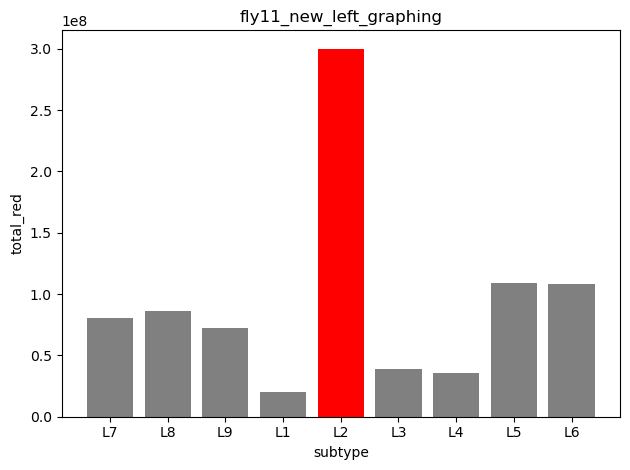

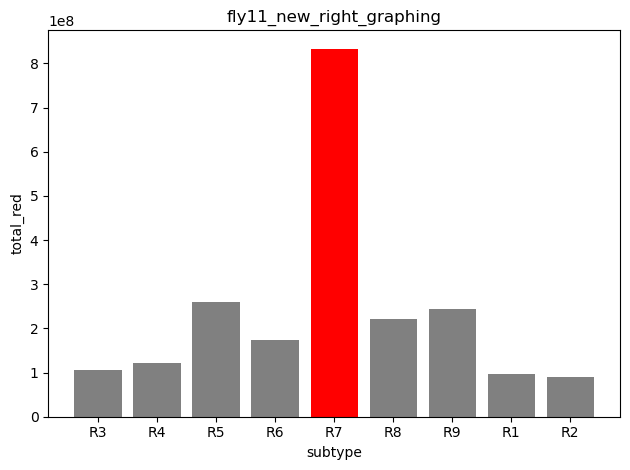

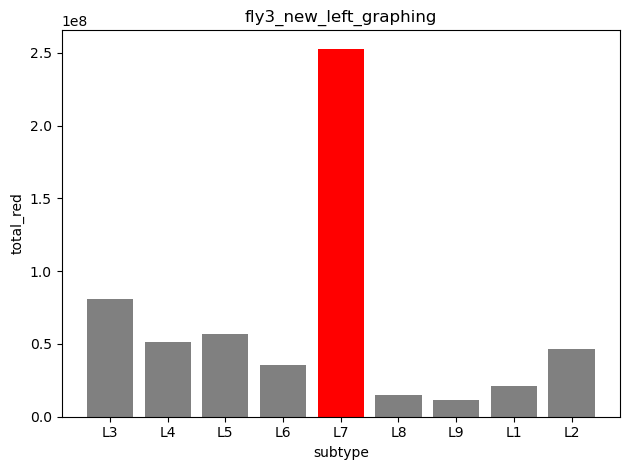

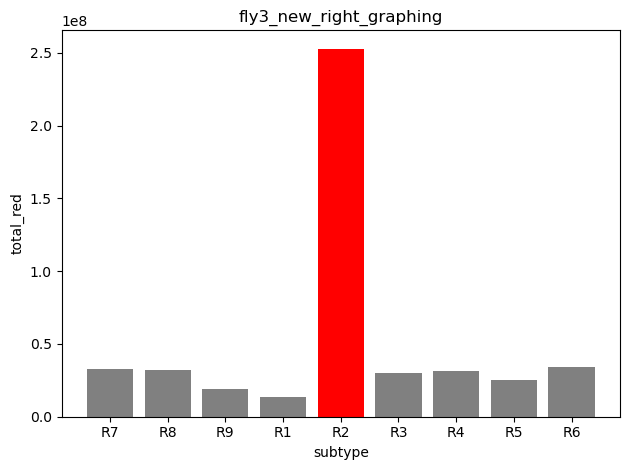

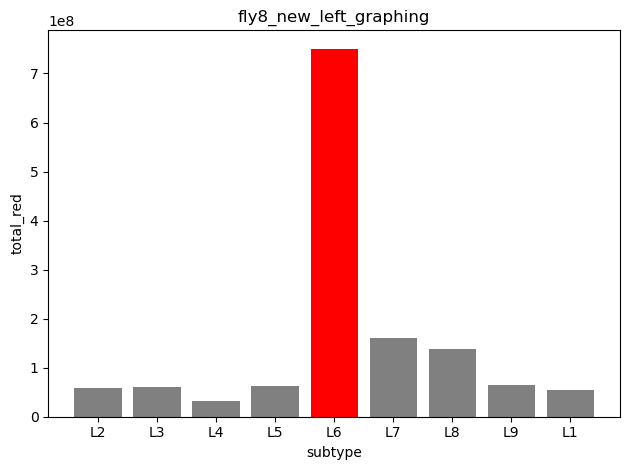

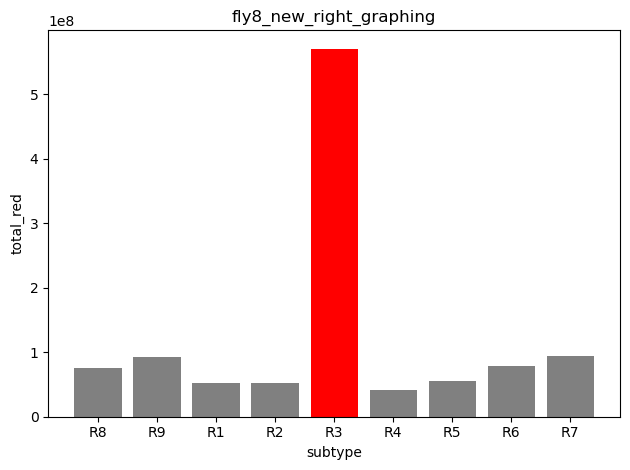

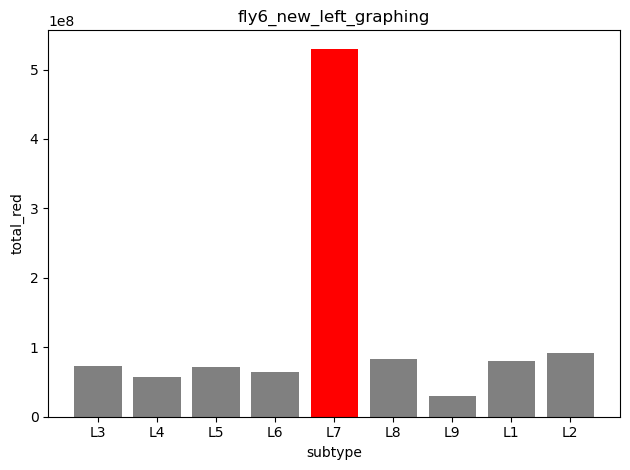

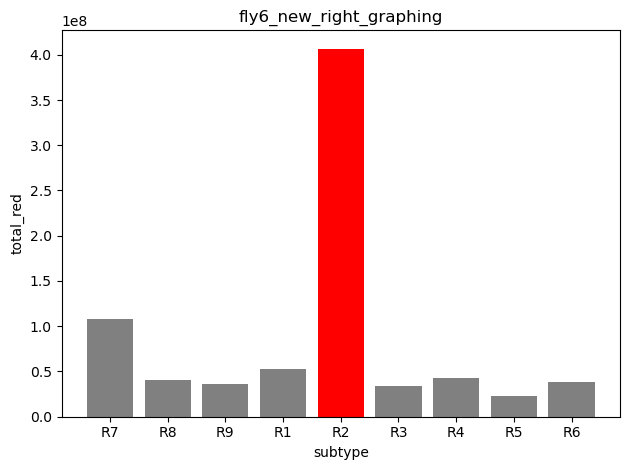

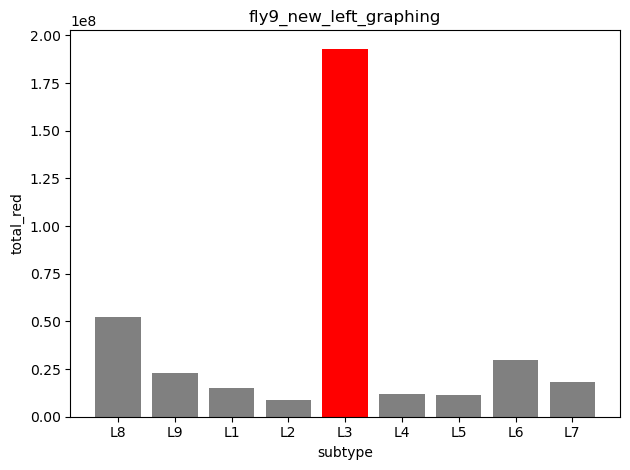

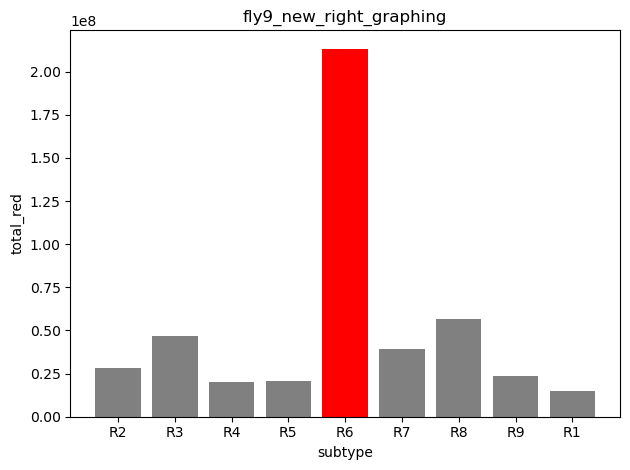

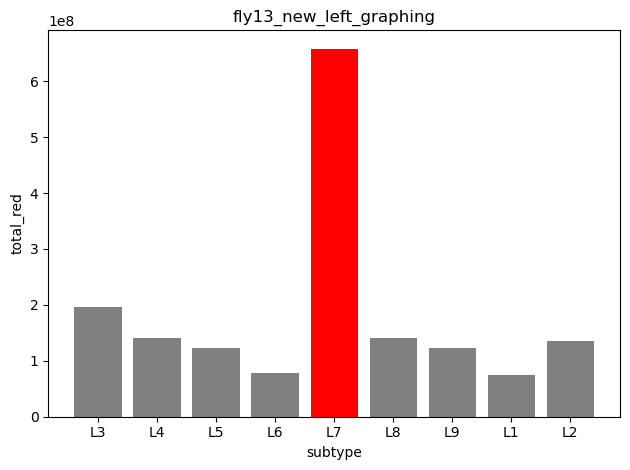

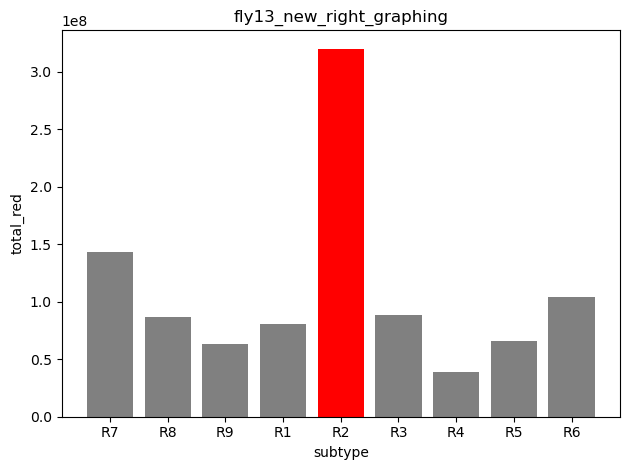

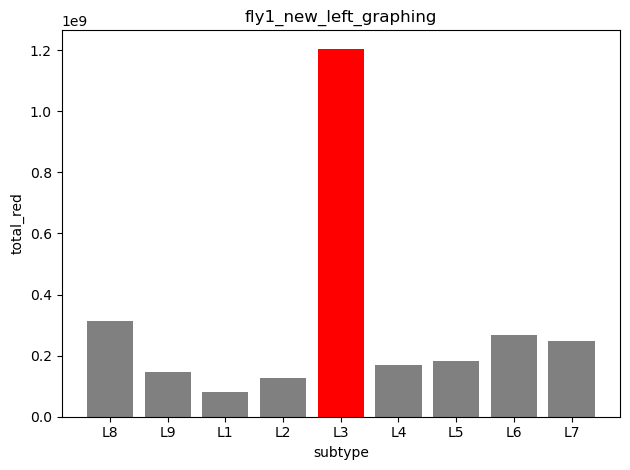

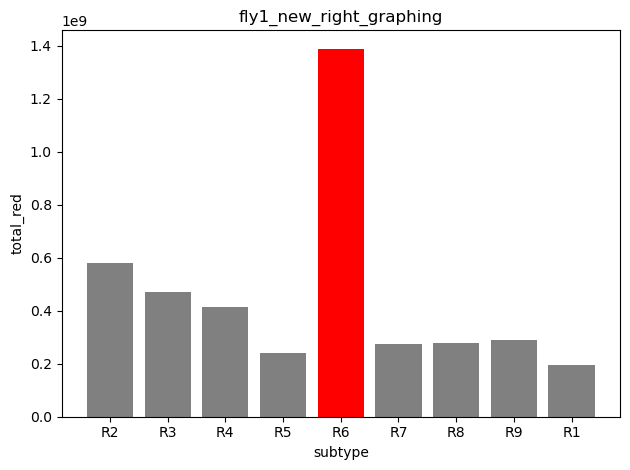

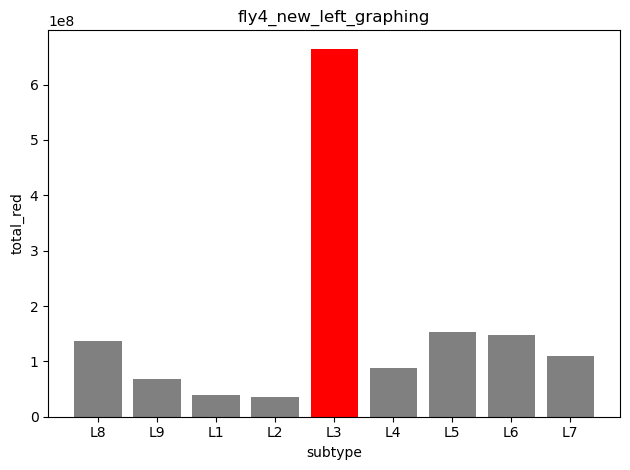

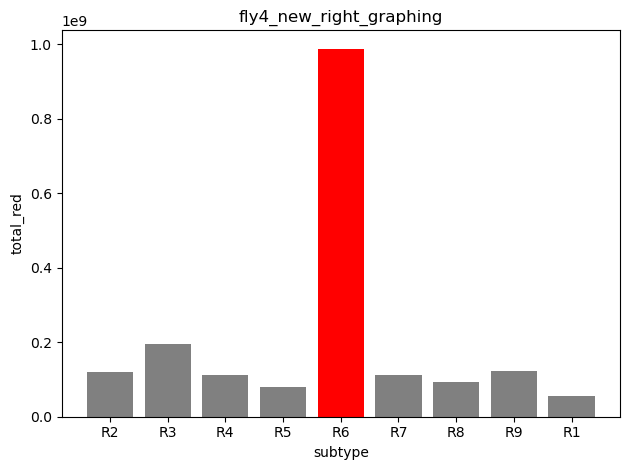

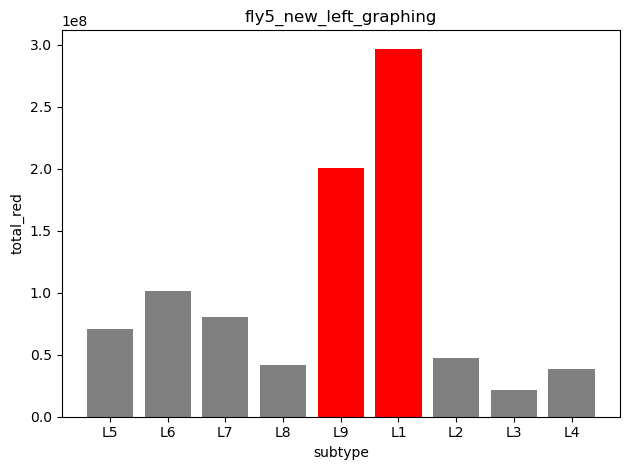

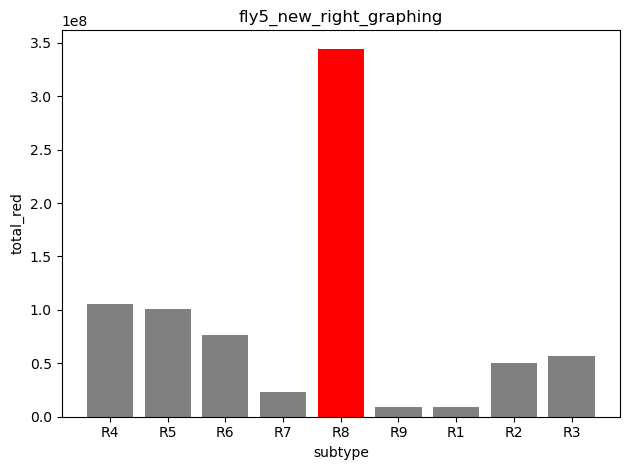

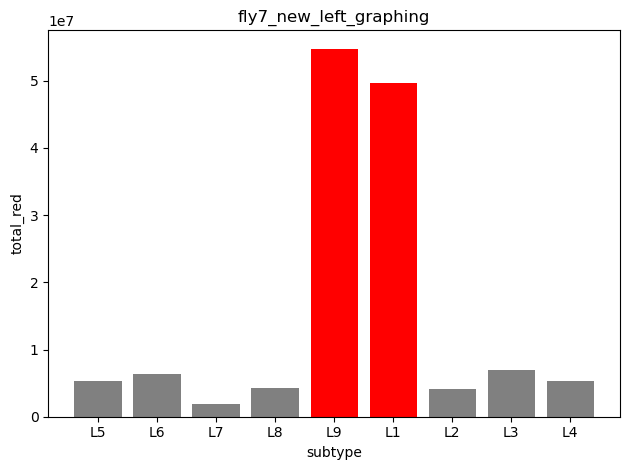

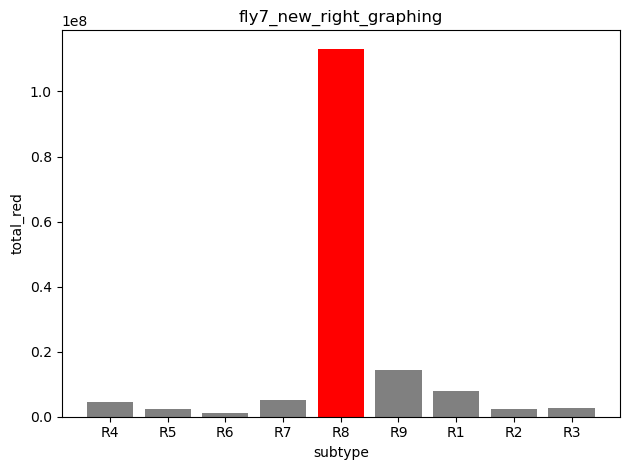

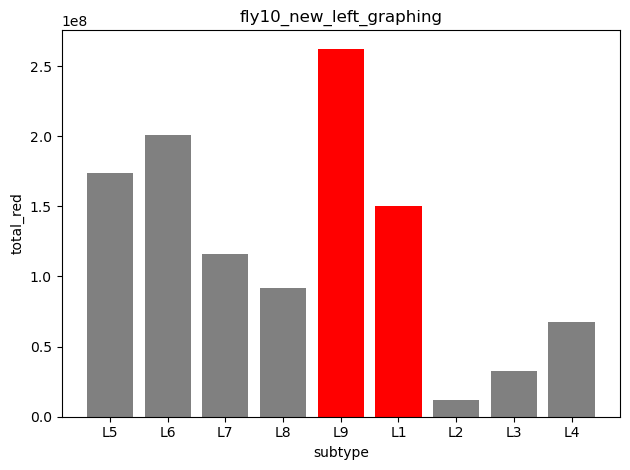

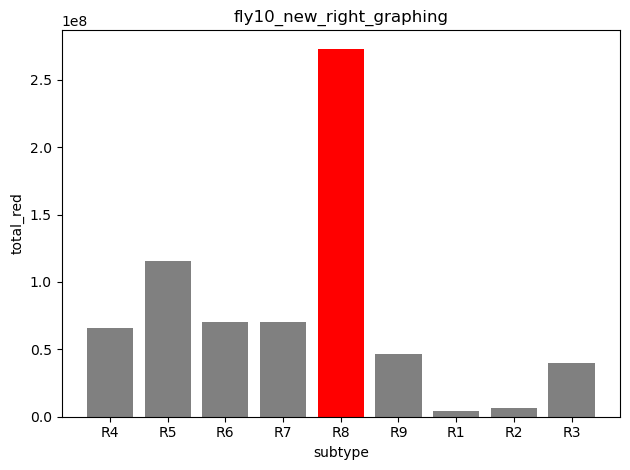

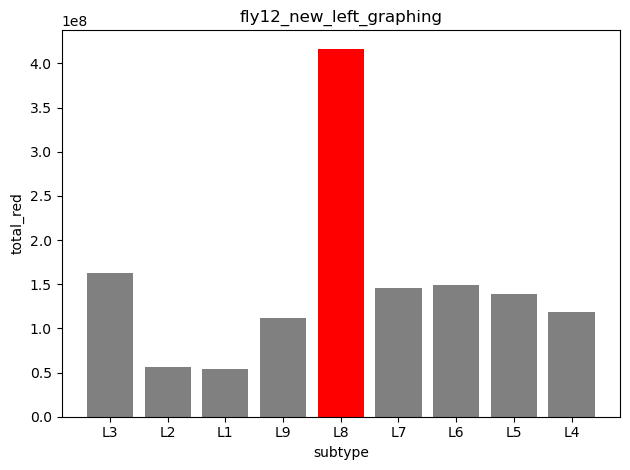

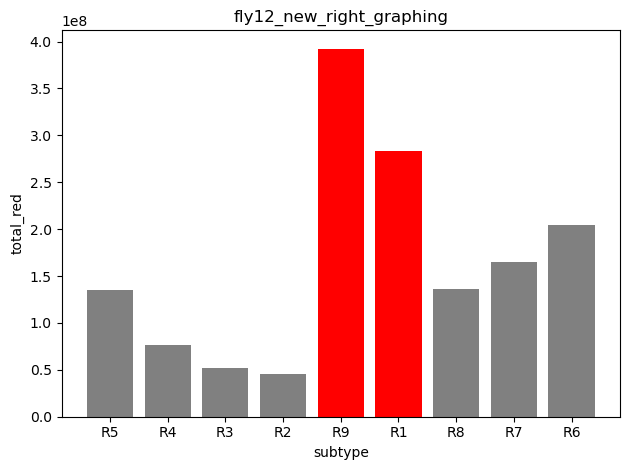

In [25]:
graphing_dfs = [
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)
]

# 2. Loop and plot, coloring all zero‐value subtypes in red
for df_name in graphing_dfs:
    df = globals()[df_name]
    if 'total_red' not in df.columns:
        continue

    x = df['subtype']
    y = df['total_red']

    # 3. Find the matching shuffle_order_for_graph table
    shuffle_name = re.sub(r'_graphing$', '_shuffle_order_for_graph', df_name)
    zeros = set()
    if shuffle_name in globals():
        shuffle_df = globals()[shuffle_name]
        # 4. Collect all subtypes where value == 0
        zeros = set(shuffle_df.loc[shuffle_df['value'] == 0, 'subtype'])

    # 5. Build colors: red for any subtype in zeros, gray otherwise
    colors = ['red' if s in zeros else 'gray' for s in x]

    # 6. Plot
    plt.figure()
    plt.bar(x, y, color=colors)
    plt.xlabel('subtype')
    plt.ylabel('total_red')
    plt.title(df_name)
    plt.tight_layout()
    plt.show()

In [26]:
graphing_dfs

['fly11_new_left_graphing',
 'fly11_new_right_graphing',
 'fly3_new_left_graphing',
 'fly3_new_right_graphing',
 'fly8_new_left_graphing',
 'fly8_new_right_graphing',
 'fly6_new_left_graphing',
 'fly6_new_right_graphing',
 'fly9_new_left_graphing',
 'fly9_new_right_graphing',
 'fly13_new_left_graphing',
 'fly13_new_right_graphing',
 'fly1_new_left_graphing',
 'fly1_new_right_graphing',
 'fly4_new_left_graphing',
 'fly4_new_right_graphing',
 'fly5_new_left_graphing',
 'fly5_new_right_graphing',
 'fly7_new_left_graphing',
 'fly7_new_right_graphing',
 'fly10_new_left_graphing',
 'fly10_new_right_graphing',
 'fly12_new_left_graphing',
 'fly12_new_right_graphing']

In [27]:
fly11_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,L7,351.401829,64.901454,80699430.0,14904619.0
1,L8,350.863610,73.966010,86544018.0,18244456.0
2,L9,412.625204,81.993197,72600992.0,14426621.0
3,L1,251.574388,42.012047,20088718.0,3354746.0
4,L2,462.065635,73.277867,300005355.0,47577121.0
5,L3,265.531938,49.687432,38676851.0,7237372.0
6,L4,258.134458,52.548538,35714193.0,7270353.0
7,L5,293.739951,69.071638,109311504.0,25704112.0
8,L6,336.546400,72.115928,107854371.0,23111280.0


In [28]:
fly5_new_right_shuffle_order_for_graph

,subtype,value
0,R3,-4
1,R2,-3
2,R1,-2
3,R9,-1
4,R8,0
5,R7,1
6,R6,2
7,R5,3
8,R4,4


In [29]:
# Regex to match fly{n}_new_{left|right}_graphing
pattern = re.compile(r'^fly(\d+)_new_(left|right)_graphing$')

# Loop through all globals
for df_name, df in list(globals().items()):
    # Check name matches and is a DataFrame
    m = pattern.match(df_name)
    if m and isinstance(df, pd.DataFrame):
        num, side = m.groups()
        
        # Build the shuffle-order DataFrame name
        shuffle_name = f"fly{num}_new_{side}_shuffle_order_for_graph"
        
        # Verify the shuffle-order DF exists
        if shuffle_name in globals() and isinstance(globals()[shuffle_name], pd.DataFrame):
            shuffle_df = globals()[shuffle_name]
            
            # New DataFrame name
            new_df_name = f"{df_name}_nan"
            
            # Copy original
            new_df = df.copy()
            
            # Mask where shuffle_df.value == 0
            mask = shuffle_df['value'] == 0
            
            # Apply zeroing
            new_df.loc[mask, 'total_red'] = 0
            
            # Inject into globals
            globals()[new_df_name] = new_df
            
            print(f"Created `{new_df_name}` with zeros applied to `total_red`.")
        else:
            print(f"Warning: `{shuffle_name}` not found or not a DataFrame.")

Created `fly11_new_left_graphing_nan` with zeros applied to `total_red`.
Created `fly11_new_right_graphing_nan` with zeros applied to `total_red`.
Created `fly3_new_left_graphing_nan` with zeros applied to `total_red`.
Created `fly3_new_right_graphing_nan` with zeros applied to `total_red`.
Created `fly8_new_left_graphing_nan` with zeros applied to `total_red`.
Created `fly8_new_right_graphing_nan` with zeros applied to `total_red`.
Created `fly6_new_left_graphing_nan` with zeros applied to `total_red`.
Created `fly6_new_right_graphing_nan` with zeros applied to `total_red`.
Created `fly9_new_left_graphing_nan` with zeros applied to `total_red`.
Created `fly9_new_right_graphing_nan` with zeros applied to `total_red`.
Created `fly13_new_left_graphing_nan` with zeros applied to `total_red`.
Created `fly13_new_right_graphing_nan` with zeros applied to `total_red`.
Created `fly1_new_left_graphing_nan` with zeros applied to `total_red`.
Created `fly1_new_right_graphing_nan` with zeros appli

In [30]:
fly12_new_right_graphing_nan

,subtype,mean_red,mean_green,total_red,total_green
0,R5,481.038454,110.753498,135144328.0,34564444.0
1,R4,434.969428,101.280847,76622933.0,19851110.0
2,R3,447.691150,91.524103,51865312.0,11985362.0
3,R2,480.752364,64.044507,0.0,7008748.0
4,R9,1033.024517,160.754970,0.0,66733892.0
5,R1,741.198776,117.993778,282763354.0,47886041.0
6,R8,677.891683,107.432029,136278073.0,25243913.0
7,R7,622.382640,129.002034,164453667.0,38606150.0
8,R6,570.260050,112.554283,204753947.0,45454046.0


In [31]:
fly1_new_right_graphing_nan

,subtype,mean_red,mean_green,total_red,total_green
0,R2,961.638081,145.755707,582224685.0,112780834.0
1,R3,1014.959324,172.429378,472628855.0,104465555.0
2,R4,947.433468,148.399130,414290294.0,88798022.0
3,R5,962.618666,155.388261,240604370.0,59908533.0
4,R6,1541.121321,267.637783,0.0,299649469.0
5,R7,1126.712897,185.496673,275695180.0,71163482.0
6,R8,1044.849375,177.634659,278943967.0,72888541.0
7,R9,1112.062175,197.914122,290232137.0,75205764.0
8,R1,778.947420,132.570087,197166664.0,42273494.0


In [32]:
special = {
    'fly12_new_right_graphing',
    'fly10_new_left_graphing',
    'fly7_new_left_graphing',
    'fly5_new_left_graphing'
}

# Regex to match all fly*_new_left_graphing and fly*_new_right_graphing DataFrames
pattern = re.compile(r'^fly\d+_new_(?:left|right)_graphing$')

# Columns to average when combining
numeric_cols = ['mean_red', 'mean_green', 'total_red', 'total_green']

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and pattern.match(name):
        df = obj
        new_name = f"{name}_combinedL1L9"

        if name in special:
            # Identify rows where subtype contains '1' or '9'
            mask = df['subtype'].astype(str).str.contains('1|9')
            combined_vals = df.loc[mask, numeric_cols].mean()

            # Build the combined row
            combined_row = {col: combined_vals[col] for col in numeric_cols}
            combined_row['subtype'] = 'L1L9'

            # Reconstruct rows: skip any row with '1', and replace the row with '9' by the combined row
            new_rows = []
            for _, row in df.iterrows():
                st = str(row['subtype'])
                if '9' in st:
                    # insert combined row at the position of the '9' row
                    new_rows.append(combined_row)
                elif '1' in st:
                    # drop any row containing '1'
                    continue
                else:
                    new_rows.append(row.to_dict())

            new_df = pd.DataFrame(new_rows).reset_index(drop=True)

        else:
            # For all other DataFrames, just copy unchanged
            new_df = df.copy()

        # Assign the new DataFrame into the global namespace
        globals()[new_name] = new_df
        print(f"Created DataFrame: {new_name}")

Created DataFrame: fly11_new_left_graphing_combinedL1L9
Created DataFrame: fly11_new_right_graphing_combinedL1L9
Created DataFrame: fly3_new_left_graphing_combinedL1L9
Created DataFrame: fly3_new_right_graphing_combinedL1L9
Created DataFrame: fly8_new_left_graphing_combinedL1L9
Created DataFrame: fly8_new_right_graphing_combinedL1L9
Created DataFrame: fly6_new_left_graphing_combinedL1L9
Created DataFrame: fly6_new_right_graphing_combinedL1L9
Created DataFrame: fly9_new_left_graphing_combinedL1L9
Created DataFrame: fly9_new_right_graphing_combinedL1L9
Created DataFrame: fly13_new_left_graphing_combinedL1L9
Created DataFrame: fly13_new_right_graphing_combinedL1L9
Created DataFrame: fly1_new_left_graphing_combinedL1L9
Created DataFrame: fly1_new_right_graphing_combinedL1L9
Created DataFrame: fly4_new_left_graphing_combinedL1L9
Created DataFrame: fly4_new_right_graphing_combinedL1L9
Created DataFrame: fly5_new_left_graphing_combinedL1L9
Created DataFrame: fly5_new_right_graphing_combinedL1

In [33]:
fly12_new_right_graphing_combinedL1L9

,subtype,mean_red,mean_green,total_red,total_green
0,R5,481.038454,110.753498,135144328.0,34564444.0
1,R4,434.969428,101.280847,76622933.0,19851110.0
2,R3,447.691150,91.524103,51865312.0,11985362.0
3,R2,480.752364,64.044507,45411068.0,7008748.0
4,L1L9,887.111646,139.374374,337536684.0,57309966.5
5,R8,677.891683,107.432029,136278073.0,25243913.0
6,R7,622.382640,129.002034,164453667.0,38606150.0
7,R6,570.260050,112.554283,204753947.0,45454046.0


In [34]:
fly12_new_right_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,R5,481.038454,110.753498,135144328.0,34564444.0
1,R4,434.969428,101.280847,76622933.0,19851110.0
2,R3,447.691150,91.524103,51865312.0,11985362.0
3,R2,480.752364,64.044507,45411068.0,7008748.0
4,R9,1033.024517,160.754970,392310014.0,66733892.0
5,R1,741.198776,117.993778,282763354.0,47886041.0
6,R8,677.891683,107.432029,136278073.0,25243913.0
7,R7,622.382640,129.002034,164453667.0,38606150.0
8,R6,570.260050,112.554283,204753947.0,45454046.0


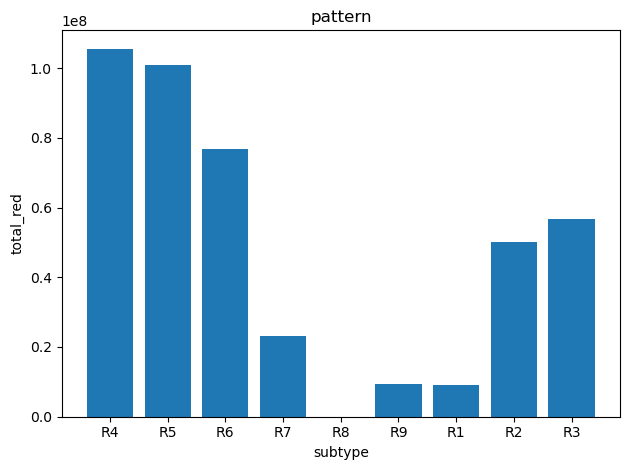

In [35]:
df = fly5_new_right_graphing_nan
x = df['subtype']
y = df['total_red']
plt.figure()
plt.bar(x, y)
plt.xlabel('subtype')
plt.ylabel('total_red')
plt.title(df_name)
plt.tight_layout()
plt.show()


Practical workflow
1. Plot all 9 points and eyeball periodic behavior.
2. Do an FFT to estimate the dominant period 𝑇≈2𝜋/𝐵
3. Fit the cosine model using that period as an initial guess for B.
4. Evaluate R^2, residuals, and (if needed) AIC/BIC against an alternative model.
5. Decide:
    1. If the cosine fit is good (high R^2, random residuals, low AIC), you can conclude “Yes, my data are well‐modeled by a cosine.”
    2. If not, you may try a different family or mixtures of sinusoids.

i am going to try cosine fitting with that one "summed" bar graph!

In [36]:
# 1) Identify all 24 combined DataFrames in globals()
pattern = re.compile(r'^fly\d+_new_(?:left|right)_graphing_combinedL1L9$')
df_names = [
    name for name, obj in globals().items()
    if isinstance(obj, pd.DataFrame) and pattern.match(name)
]

# 2) Prepare an accumulator for the 9 possible rows
num_rows = 9  # corresponding to glomerulus -4, -3, …, 4
sum_totals = [0.0] * num_rows # this creates a list of 9 0.0, and each can be accessed by calling sum_totals[i]

# 3) Loop over each DataFrame and add its total_red values row-wise
for name in df_names:
    df = globals()[name]
    for idx, value in enumerate(df['total_red']):
        if idx < num_rows:
            sum_totals[idx] += value
        # else: ignore any extra rows beyond the 9th

# 4) Build the final sum_all DataFrame
glomerulus = list(range(-4, 5))  # [-4, -3, …, 4]
sum_all = pd.DataFrame({
    'glomerulus': glomerulus,
    'total_red':  sum_totals
})

# Now sum_all contains one row per glomerulus with the summed total_red
print(sum_all)



   glomerulus     total_red
0          -4  2.911377e+09
1          -3  2.381329e+09
2          -2  1.920714e+09
3          -1  1.540271e+09
4           0  1.152067e+10
5           1  1.966448e+09
6           2  1.921752e+09
7           3  2.038028e+09
8           4  1.658429e+09


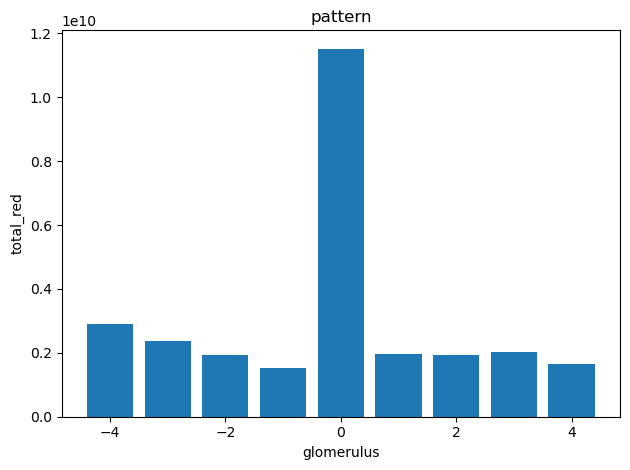

In [37]:
df = sum_all
x = df['glomerulus']
y = df['total_red']
plt.figure()
plt.bar(x, y)
plt.xlabel('glomerulus')
plt.ylabel('total_red')
plt.title(df_name)
plt.tight_layout()
plt.show()

In [38]:
sum_all_nan = sum_all.copy()
sum_all_nan.loc[4, 'total_red'] = np.nan
sum_all_nan

,glomerulus,total_red
0,-4,2.911377e+09
1,-3,2.381329e+09
2,-2,1.920714e+09
3,-1,1.540271e+09
4,0,NaN
5,1,1.966448e+09
6,2,1.921752e+09
7,3,2.038028e+09
8,4,1.658429e+09


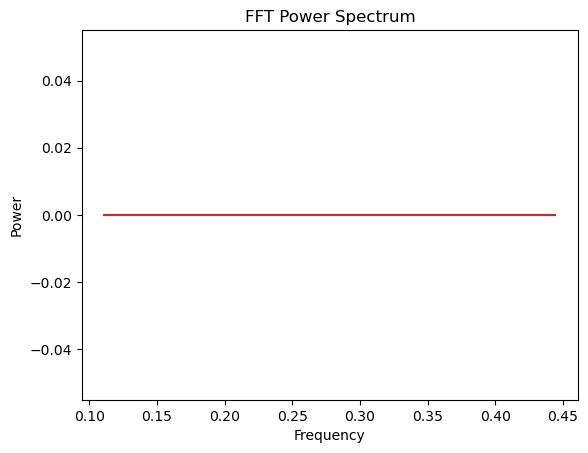

Estimated period T ≈ 9.000, angular frequency B ≈ 0.698


In [39]:
# --- Step 2: FFT to estimate dominant period ---

# Assume df = fly5_new_right_graphing_nan already exists
df = sum_all_nan

# Extract x and y
if 'frame' in df.columns:
    x = df['frame'].to_numpy()
else:
    x = np.arange(len(df))
y = df['total_red'].to_numpy()

# Detrend (subtract mean)
y_detrended = y - np.mean(y)
n = len(y_detrended)
dx = x[1] - x[0]  # assumes uniform spacing

# Compute FFT
yf = fft(y_detrended)
xf = fftfreq(n, dx)

# Keep only positive frequencies
pos_mask = xf > 0
xf_pos = xf[pos_mask]
power = np.abs(yf[pos_mask])

# Find peak frequency
idx_peak = np.argmax(power)
freq_peak = xf_pos[idx_peak]
T_est = 1.0 / freq_peak
B_est = 2 * np.pi / T_est

# Plot FFT power spectrum (without use_line_collection)
plt.figure()
plt.stem(xf_pos, power)
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('FFT Power Spectrum')
plt.show()

print(f"Estimated period T ≈ {T_est:.3f}, angular frequency B ≈ {B_est:.3f}")

In [40]:
sum_all_nan_removed = sum_all_nan[sum_all_nan['total_red'].notna()].copy()
sum_all_nan_removed

,glomerulus,total_red
0,-4,2.911377e+09
1,-3,2.381329e+09
2,-2,1.920714e+09
3,-1,1.540271e+09
5,1,1.966448e+09
6,2,1.921752e+09
7,3,2.038028e+09
8,4,1.658429e+09


In [41]:
df = sum_all_nan_removed

def cos_model(x, A, omega, phi, C):
    """
    A⋅cos(ω x + φ) + C
      A     = amplitude (depth of oscillation). should be the "amplitude", which is half of the difference between the max and the min.
      ω     = angular frequency (controls how many oscillations over your x-range). should=2pi/period, where period is how many point will the data repeat itself.
      φ     = phase shift (moves the peaks/dips left or right). should be {-[the difference between [the x value of the y max] and [the x value of the current y max]] * [ω]}. --> in this vedio, phi is the last to calculate: https://www.youtube.com/watch?v=0LKYnB9pBpA
      C     = vertical offset (raises/lowers the whole curve). should be the middle of the max and min because this value shift the curve up and down.
    """
    return A * np.cos(omega * x + phi) + C


x = np.arange(len(df))
y = df['total_red'].to_numpy()

p0 = [(y.max()-y.min())/2, np.pi/4, 0, y.mean()]

popt, pcov = curve_fit(cos_model, x, y, p0=p0)
A_fit, ω_fit, φ_fit, C_fit = popt

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

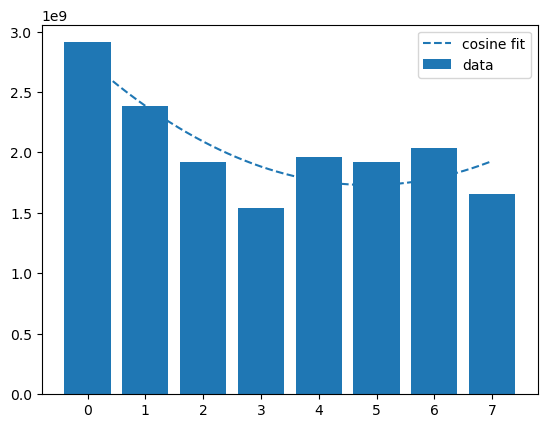

In [ ]:
xs = np.linspace(0,7,200)
plt.bar(x, y, label="data")
plt.plot(xs, cos_model(xs, *popt), "--", label="cosine fit")
plt.legend()
plt.show()

<BarContainer object of 9 artists>

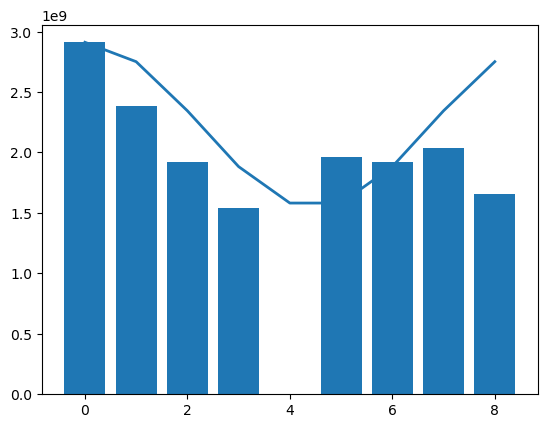

In [ ]:
# sansa_cosine_fit is able to leave the axon terminal bar blank


df=sum_all_nan


max_value = df['total_red'].max()
min_value = df['total_red'].min()
A=(max_value-min_value)/2
C=(max_value+min_value)/2
W=2*(math.pi)/9
max_index = df['total_red'].idxmax()
phi=-W*(max_index)

#t = df['glomerulus'].values
sansa_cosine_fit = C + A * np.cos(W * x + phi)

df_nan_filled = sum_all_nan.fillna(0) # because plt make take real number

x=np.arange(len(df_nan_filled))
y=df_nan_filled["total_red"]
plt.plot(x, sansa_cosine_fit, label='Cosine Fit', linewidth=2)
plt.bar(x, y, label="data")


([<matplotlib.axis.XTick at 0x17c781b50>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, 'axon terminal'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8')])

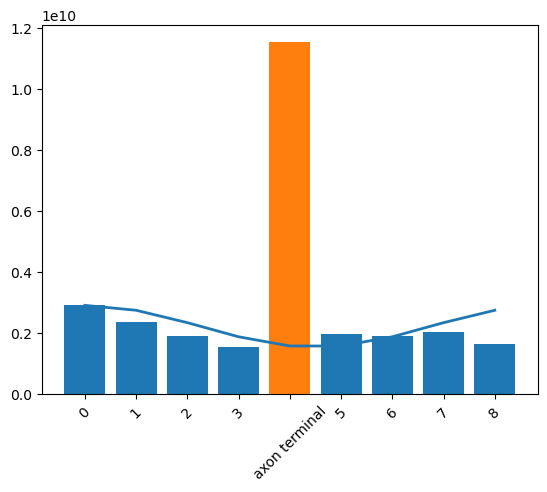

In [50]:
# sansa_cosine_fit is able to leave the axon terminal bar blank


df=sum_all_nan


max_value = df['total_red'].max()
min_value = df['total_red'].min()
A=(max_value-min_value)/2
C=(max_value+min_value)/2
W=2*(math.pi)/9
max_index = df['total_red'].idxmax()
phi=-W*(max_index)

#t = df['glomerulus'].values
sansa_cosine_fit = C + A * np.cos(W * x + phi)

df_nan_filled = sum_all_nan.fillna(0) # because plt make take real number

x=np.arange(len(df_nan_filled))
y=df_nan_filled["total_red"]
plt.plot(x, sansa_cosine_fit, label='Cosine Fit', linewidth=2)
plt.bar(x, y, label="data")

fifth_val = sum_all.iloc[4]['total_red']
plt.bar(4, fifth_val, color='C1', label='5th row')

labels = df.index.tolist()
labels[4] = "axon terminal"
plt.xticks(x, labels, rotation=45)

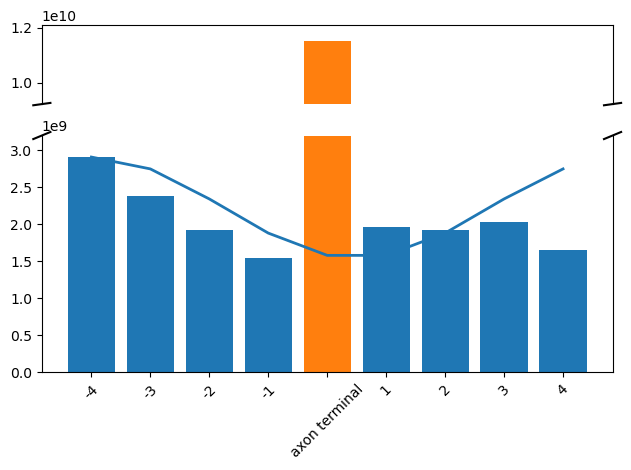

In [57]:
df = sum_all_nan

max_value = df['total_red'].max()
min_value = df['total_red'].min()
A = (max_value - min_value) / 2
C = (max_value + min_value) / 2
W = 2 * math.pi / 9
max_index = df['total_red'].idxmax()
phi = -W * max_index

x = np.arange(len(df))
sansa_cosine_fit = C + A * np.cos(W * x + phi)

y = df['total_red'].fillna(0).values
fifth_val = sum_all.iloc[4]['total_red']

labels = df.index.tolist()
labels[4] = "axon terminal"
labels=[-4, -3, -2, -1, "axon terminal", 1, 2, 3, 4]
# — create two stacked axes —
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True,
    gridspec_kw={'height_ratios': [1, 3]}
)

# plot on both
for ax in (ax_top, ax_bot):
    ax.plot(x, sansa_cosine_fit, label='Cosine Fit', linewidth=2)
    ax.bar(x, y, label='Data')
    ax.bar(4, fifth_val, color='C1', label='5th row')

# set the y-limits
visible_max = max(y.max(), sansa_cosine_fit.max())
ax_bot.set_ylim(0, visible_max * 1.1)
ax_top.set_ylim(fifth_val * 0.8, fifth_val * 1.05)

# remove the middle spines
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)

# draw the diagonal marks
d = .015
kwargs = dict(color='k', clip_on=False)
# top axes slashes
ax_top.plot((-d, +d), (-d, +d), transform=ax_top.transAxes, **kwargs)
ax_top.plot((1-d, 1+d), (-d, +d), transform=ax_top.transAxes, **kwargs)
# bottom axes slashes
ax_bot.plot((-d, +d), (1-d, 1+d), transform=ax_bot.transAxes, **kwargs)
ax_bot.plot((1-d, 1+d), (1-d, 1+d), transform=ax_bot.transAxes, **kwargs)

# ─── HERE: Remove the unwanted ticks in the “break” region ───
# 1) No x-ticks on the top plot
ax_top.tick_params(labelbottom=False, bottom=False)
# 2) No top y-ticks on the bottom plot
ax_bot.tick_params(labeltop=False, top=False)

# set x-ticks & labels on the bottom plot only
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(labels, rotation=45)

#ax_bot.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [61]:
sum_all_nan_fill0 = sum_all_nan.fillna(0)
sum_all_nan_fill0

,glomerulus,total_red
0,-4,2.911377e+09
1,-3,2.381329e+09
2,-2,1.920714e+09
3,-1,1.540271e+09
4,0,0.000000e+00
5,1,1.966448e+09
6,2,1.921752e+09
7,3,2.038028e+09
8,4,1.658429e+09


In [64]:
df = sum_all_nan_fill0

def cos_model(x, A, omega, phi, C):
    """
    A⋅cos(ω x + φ) + C
      A     = amplitude (depth of oscillation). should be the "amplitude", which is half of the difference between the max and the min.
      ω     = angular frequency (controls how many oscillations over your x-range). should=2pi/period, where period is how many point will the data repeat itself.
      φ     = phase shift (moves the peaks/dips left or right). should be {-[the difference between [the x value of the y max] and [the x value of the current y max]] * [ω]}. --> in this vedio, phi is the last to calculate: https://www.youtube.com/watch?v=0LKYnB9pBpA
      C     = vertical offset (raises/lowers the whole curve). should be the middle of the max and min because this value shift the curve up and down.
    """
    return A * np.cos(omega * x + phi) + C


x = np.arange(len(df))
y = df['total_red'].to_numpy()

p0 = [(y.max()-y.min())/2, 2*np.pi / 9, 0, y.mean()]

popt, pcov = curve_fit(cos_model, x, y, p0=p0)
A_fit, ω_fit, φ_fit, C_fit = popt

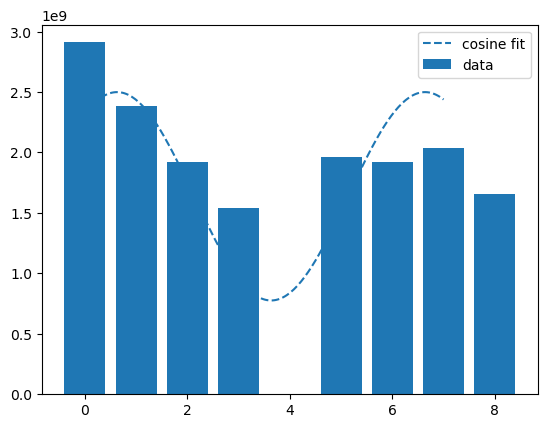

In [65]:
xs = np.linspace(0,7,200)
plt.bar(x, y, label="data")
plt.plot(xs, cos_model(xs, *popt), "--", label="cosine fit")
plt.legend()
plt.show()

In [67]:
df = sum_all_nan_fill0


x = np.arange(len(df))            # [0,1,2,…,8]
y = df['total_red'].to_numpy()

# 2. Define the cosine model
def cos_model(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C

# 3. Build a better initial guess:
A0     = (y.max() - y.min()) / 2        # half the peak-to-trough
omega0 = 2 * np.pi / len(df)            # one cycle over 9 points
phi0   = 0                              # you can also use -omega0 * argmax to shift
C0     = y.mean()                      # vertical center
p0 = [A0, omega0, phi0, C0]

# 4. Fit
popt, pcov = curve_fit(cos_model, x, y, p0=p0)
A_fit, omega_fit, phi_fit, C_fit = popt

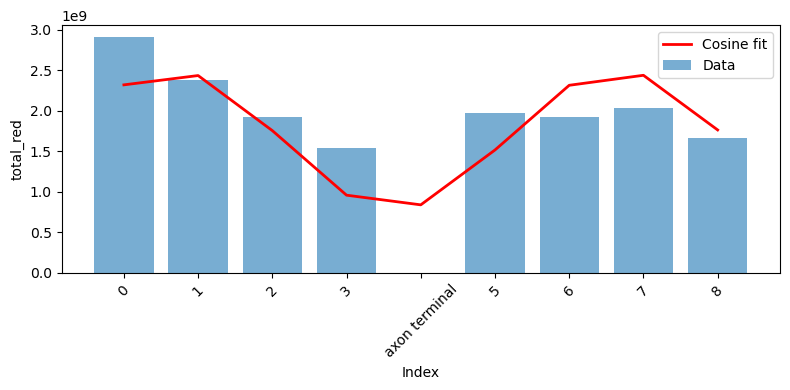

In [70]:
y_fit = cos_model(x, A_fit, omega_fit, phi_fit, C_fit)

plt.figure(figsize=(8,4))
plt.bar(x, y, label='Data', alpha=0.6)
plt.plot(x, y_fit, 'r-', linewidth=2, label='Cosine fit')

# 7. Optional: label the “axon terminal” at position 4
labels = df.index.tolist()
labels[4] = "axon terminal"
plt.xticks(x, labels, rotation=45)

plt.xlabel('Index')
plt.ylabel('total_red')
plt.legend()
plt.tight_layout()
plt.show()

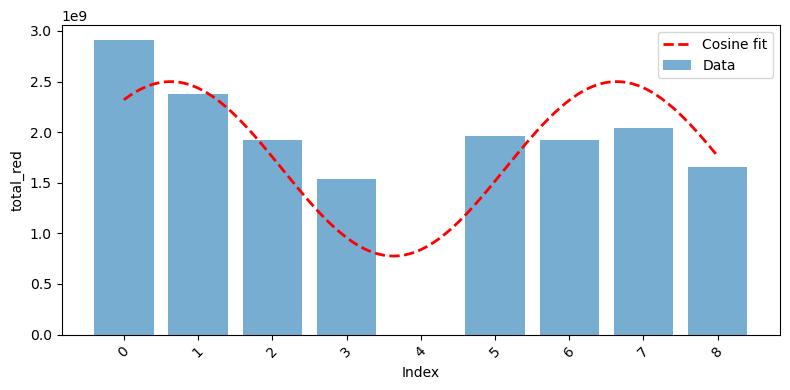

In [71]:
df = sum_all_nan_fill0


def cos_model(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi) + C

# 3. Prepare x and y
x = np.arange(len(df))              # [0, 1, 2, …, 8]
y = df['total_red'].to_numpy()

# 4. Initial guess: one cycle over 9 points
A0     = (y.max() - y.min()) / 2
omega0 = 2 * np.pi / len(df)        # = 2π/9
phi0   = 0
C0     = y.mean()
p0     = [A0, omega0, phi0, C0]

# 5. Fit
popt, pcov = curve_fit(cos_model, x, y, p0=p0)
A_fit, omega_fit, phi_fit, C_fit = popt

# 6. Build a smooth x-axis and compute the smooth curve
xs = np.linspace(0, len(df)-1, 200)  # 200 points between 0 and 8
y_fit = cos_model(xs, A_fit, omega_fit, phi_fit, C_fit)

# 7. Plot
plt.figure(figsize=(8, 4))
plt.bar(x, y, alpha=0.6, label='Data')
plt.plot(xs, y_fit, 'r--', linewidth=2, label='Cosine fit')
plt.xticks(x, df.index.tolist(), rotation=45)
plt.xlabel('Index')
plt.ylabel('total_red')
plt.legend()
plt.tight_layout()
plt.show()